<a href="https://colab.research.google.com/github/SantosGuarilha/fonte_dados/blob/main/analisesorvete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análise de dados sobre sorvete

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshisatre/ice-cream-sales-dataset")

print("caminho para os arquivos conjuntos de dados:", path)

Using Colab cache for faster access to the 'ice-cream-sales-dataset' dataset.
caminho para os arquivos conjuntos de dados: /kaggle/input/ice-cream-sales-dataset


In [2]:
import pandas as pd

file_path = f"{path}/Ice Cream.csv"
df_icecream = pd.read_csv(file_path)

print("DataFrame 'df_icecream' criado com sucesso. Primeiras 5 linhas:")
print(df_icecream.head())

DataFrame 'df_icecream' criado com sucesso. Primeiras 5 linhas:
   Temperature  Revenue
0         24.6      535
1         26.1      626
2         27.8      661
3         20.6      488
4         11.6      317


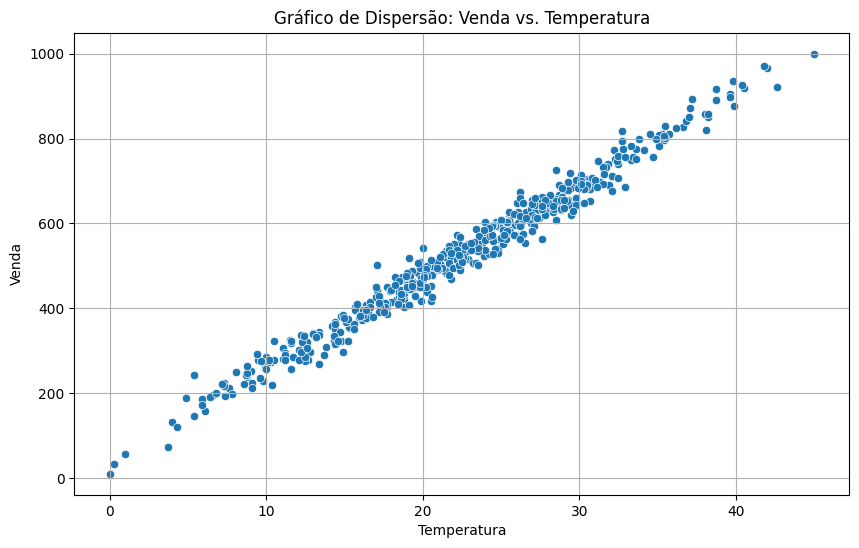

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Revenue', data=df_icecream)
plt.title('Gráfico de Dispersão: Venda vs. Temperatura')
plt.xlabel('Temperatura')
plt.ylabel('Venda')
plt.grid(True)
plt.show()

### Modelo de Regressão Linear

Vamos construir um modelo de regressão linear para prever a receita com base na temperatura.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Preparar os dados
X = df_icecream[['Temperature']]
y = df_icecream['Revenue']

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {len(X_train)}")
print(f"Tamanho do conjunto de teste: {len(X_test)}")

Tamanho do conjunto de treino: 400
Tamanho do conjunto de teste: 100


#### Treinando o Modelo de Regressão Linear

In [6]:
# Criar e treinar o modelo
model = LinearRegression()
model.fit(X_train, y_train)

print("Modelo de Regressão Linear treinado com sucesso.")
print(f"Coeficiente (inclinação): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

Modelo de Regressão Linear treinado com sucesso.
Coeficiente (inclinação): 21.38
Intercepto: 46.18


#### Fazendo Previsões e Avaliando o Modelo

In [7]:
# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")

Erro Quadrático Médio (MSE): 652.49
Coeficiente de Determinação (R²): 0.98


Um valor de R² próximo de 1 indica que o modelo explica uma grande proporção da variância da variável dependente.

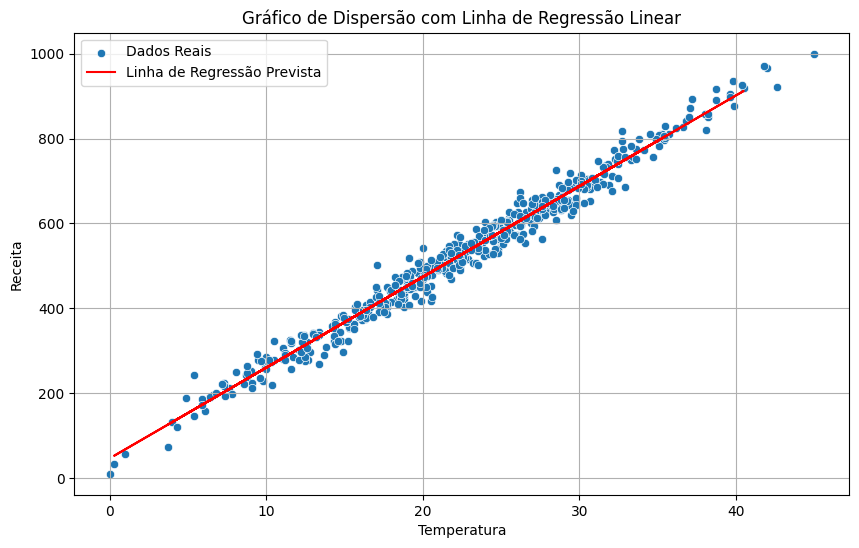

In [9]:
# Visualizar as previsões do modelo em relação aos dados reais
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Revenue', data=df_icecream, label='Dados Reais')
plt.plot(X_test, y_pred, color='red', label='Linha de Regressão Prevista')
plt.title('Gráfico de Dispersão com Linha de Regressão Linear')
plt.xlabel('Temperatura')
plt.ylabel('Receita')
plt.legend()
plt.grid(True)
plt.show()